In [ ]:
import kagglehub

In [ ]:
path = kagglehub.dataset_download("karakaggle/kaggle-cat-vs-dog-dataset")

In [ ]:
path

'/kaggle/input/kaggle-cat-vs-dog-dataset'

In [ ]:
!ls /root/.cache/kagglehub/datasets/karakaggle/kaggle-cat-vs-dog-dataset/versions/1/kagglecatsanddogs_3367a

'MSR-LA - 3467.docx'   PetImages  'readme[1].txt'


In [ ]:
import cv2
import matplotlib.pyplot as plt

In [ ]:
img = cv2.imread("/root/.cache/kagglehub/datasets/karakaggle/kaggle-cat-vs-dog-dataset/versions/1/kagglecatsanddogs_3367a/PetImages/Cat/50.jpg")
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

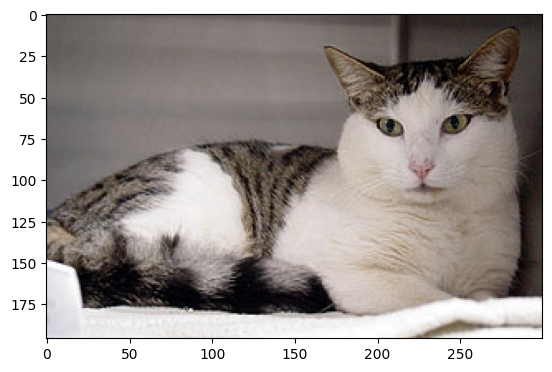

In [ ]:
plt.imshow(img)

In [ ]:
import os
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import glob
import numpy as np

In [ ]:
image_path_list = glob.glob("/kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages/Cat/*.jpg")

In [ ]:
class CatsVsDogsDataset(Dataset):
  def __init__(self, root_dir, transform=None):
    self.root_dir = root_dir
    self.transform = transform

    self.image_paths = []
    self.labels = []

    for cls_idx, class_name in enumerate(["Cat", "Dog"]):
      class_dir = os.path.join(root_dir, class_name, "*.jpg") # e.g. /kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages/Cat/*.jpg
      images_path_list = glob.glob(class_dir)
      for img_path in images_path_list:
        self.image_paths.append(img_path)
        self.labels.append(cls_idx)


  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, index):
    img_path = self.image_paths[index]
    label = self.labels[index]

    # Load image
    image = Image.open(img_path).convert("RGB")

    if self.transform:
      image = self.transform(image)

    return image, label

In [ ]:
root_dir = "/root/.cache/kagglehub/datasets/karakaggle/kaggle-cat-vs-dog-dataset/versions/1/kagglecatsanddogs_3367a/PetImages"

In [ ]:
data_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize([.5,.5,.5], [.5,.5,.5])
])

In [ ]:
dataset = CatsVsDogsDataset(root_dir, data_transform)

In [ ]:
train_size = int(0.8*len(dataset))
val_size = len(dataset)- train_size
train_set, val_set = torch.utils.data.random_split(dataset,[train_size, val_size])

In [ ]:
print(len(train_set))
print(len(val_set))

19967
4992


In [ ]:
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=8)

# Alex Net

In [ ]:
import torch
import torch.nn as nn

In [ ]:
class AlexNet(nn.Module):
  def __init__(self):
    super(AlexNet, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),

        nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),

        nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),

        nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),

        nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),
    )

    self.classifier = nn.Sequential(
        nn.Dropout(),
        nn.Linear(2304, 1024),
        nn.ReLU(),

        nn.Linear(1024, 128),
        nn.ReLU(),

        nn.Linear(128, 2)
    )
    self.flatten = nn.Flatten()

  def forward(self, x):
    x = self.features(x)
    # print(x.shape)
    x = self.flatten(x)
    # print(x.shape)
    x = self.classifier(x)
    # print(x.shape)

    return x

In [ ]:
model = AlexNet()

In [ ]:
import numpy as np

In [ ]:
dummy_image = np.zeros((1, 3, 512, 512), dtype=np.float32)
input_tensor = torch.from_numpy(dummy_image)

In [ ]:
input_tensor.shape

torch.Size([1, 3, 512, 512])

In [ ]:
with torch.no_grad():
  output = model(input_tensor)

In [ ]:
print(model)

VGGNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU()
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (17): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), 

In [ ]:
(2304*1024)

2359296

In [ ]:
sum = 0
for p in model.parameters():
  sum += p.numel()
  print(p.numel())

print(f"Total parameters : {sum}")

34848
96
614400
256
884736
384
1327104
384
884736
256
2359296
1024
131072
128
256
2
Total parameters : 6238978


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 2

In [ ]:
import tqdm

In [ ]:
for epoch in range(num_epochs):
  model.train()

  epoch_loss = 0.0
  for images, labels in tqdm.tqdm(train_loader):
    images, labels = images.to(device), labels.to(device)

    # Forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()

  print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss}")

  0%|          | 1/624 [00:05<53:52,  5.19s/it]


OutOfMemoryError: CUDA out of memory. Tried to allocate 512.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 52.12 MiB is free. Process 3559 has 14.69 GiB memory in use. Of the allocated memory 13.47 GiB is allocated by PyTorch, and 1.09 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
model.eval()
with torch.no_grad():
  num_correct = 0
  num_samples = 0

  for data, targets in tqdm.tqdm(val_loader):
    data, targets = data.to(device), targets.to(device)

    outputs = model(data)
    _, predictions = torch.max(outputs, 1)
    num_correct += (predictions == targets).sum()

    num_samples += targets.size(0)

100%|██████████| 624/624 [00:46<00:00, 13.40it/s]


In [ ]:
num_correct / num_samples

tensor(0.4984, device='cuda:0')

# VGG Model

In [ ]:
class VGGNet(nn.Module):
  def __init__(self, num_classes):
    super(VGGNet, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(64, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(256, 512, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(512, 1024, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(1024, 2048, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(2048, 2048, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(2048, 2048, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(2048, 2048, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(2048, 2048, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(2048, 2048, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )

    self.classifier = nn.Sequential(
        nn.Linear(2048, 512),
        nn.ReLU(),
        nn.Dropout(p=0.5),

        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Dropout(p=0.5),

        nn.Linear(128, num_classes)
    )
    self.flatten = nn.Flatten()

  def forward(self, x):
    x = self.features(x)
    # print(x.shape)
    x = self.flatten(x)
    # print(x.shape)
    x = self.classifier(x)

    return x

In [ ]:
model = VGGNet(2)

In [ ]:
import numpy as np

In [ ]:
dummy_image = np.zeros((1, 3, 512, 512), dtype=np.float32)
input_tensor = torch.from_numpy(dummy_image)

In [ ]:
input_tensor.shape

torch.Size([1, 3, 512, 512])

In [ ]:
with torch.no_grad():
  output = model(input_tensor)

In [ ]:
print(model)

VGGNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU()
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (17): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), 

In [ ]:
(2304*1024)

2359296

In [ ]:
sum = 0
for p in model.parameters():
  sum += p.numel()
  print(p.numel())

print(f"Total parameters : {sum}")

1728
64
36864
64
73728
128
147456
128
294912
256
589824
256
589824
256
1179648
512
2359296
512
2359296
512
2359296
512
2359296
512
2359296
512
4718592
1024
9437184
1024
9437184
1024
9437184
1024
9437184
1024
9437184
1024
18874368
2048
37748736
2048
37748736
2048
37748736
2048
37748736
2048
37748736
2048
1048576
512
65536
128
256
2
Total parameters : 275370690


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 2

In [ ]:
import tqdm

In [ ]:
for epoch in range(num_epochs):
  model.train()

  epoch_loss = 0.0
  for images, labels in tqdm.tqdm(train_loader):
    images, labels = images.to(device), labels.to(device)

    # Forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()

  print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss}")

 10%|▉         | 248/2496 [03:44<33:57,  1.10it/s]


KeyboardInterrupt: 

In [ ]:
model.eval()
with torch.no_grad():
  num_correct = 0
  num_samples = 0

  for data, targets in tqdm.tqdm(val_loader):
    data, targets = data.to(device), targets.to(device)

    outputs = model(data)
    _, predictions = torch.max(outputs, 1)
    num_correct += (predictions == targets).sum()

    num_samples += targets.size(0)

100%|██████████| 624/624 [00:46<00:00, 13.40it/s]


In [ ]:
num_correct / num_samples

tensor(0.4984, device='cuda:0')

In [ ]:
from torchvision import models

In [ ]:
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([.5,.5,.5], [.5,.5,.5])
])

In [ ]:
dataset = CatsVsDogsDataset(root_dir, data_transform)

In [ ]:
train_size = int(0.8*len(dataset))
val_size = len(dataset)- train_size
train_set, val_set = torch.utils.data.random_split(dataset,[train_size, val_size])

In [ ]:
print(len(train_set))
print(len(val_set))

19967
4992


In [ ]:
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=8)

In [ ]:
model = models.vgg16(pretrained=True)

In [ ]:
sum = 0
for p in model.parameters():
  sum += p.numel()
  print(p.numel())

print(f"Total parameters : {sum}")

1728
64
36864
64
73728
128
147456
128
294912
256
589824
256
589824
256
1179648
512
2359296
512
2359296
512
2359296
512
2359296
512
2359296
512
102760448
4096
16777216
4096
4096000
1000
Total parameters : 138357544


In [ ]:
for param in model.features.parameters():
  param.requires_grad = False

In [ ]:
model.classifier[6]

Linear(in_features=4096, out_features=1000, bias=True)

In [ ]:
num_features = model.classifier[6].in_features

In [ ]:
num_features

4096

In [ ]:
model.classifier[6] = nn.Linear(num_features, 2)

In [ ]:
model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=2, bias=True)
)

In [ ]:
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 2

In [ ]:
import tqdm

In [ ]:
for epoch in range(num_epochs):
  model.train()

  epoch_loss = 0.0
  for images, labels in tqdm.tqdm(train_loader):
    images, labels = images.to(device), labels.to(device)

    # Forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()

  print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss}")

 33%|███▎      | 827/2496 [01:36<03:08,  8.83it/s]/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 2496/2496 [04:48<00:00,  8.65it/s]


Epoch 1/2, Loss: 5265.026019093724


100%|██████████| 2496/2496 [04:53<00:00,  8.50it/s]

Epoch 2/2, Loss: 3454.4213790777358


In [ ]:
model.eval()
with torch.no_grad():
  num_correct = 0
  num_samples = 0

  for data, targets in tqdm.tqdm(val_loader):
    data, targets = data.to(device), targets.to(device)

    outputs = model(data)
    _, predictions = torch.max(outputs, 1)
    num_correct += (predictions == targets).sum()

    num_samples += targets.size(0)

  0%|          | 0/624 [00:00<?, ?it/s]


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [ ]:
num_correct / num_samples

ZeroDivisionError: division by zero

# ResNet

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class BasicBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super(BasicBlock, self).__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, stride=stride, kernel_size=3, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, stride=1, kernel_size=3, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)

    self.shortcut = nn.Sequential()
    if stride !=1 or in_channels != out_channels:
      self.shortcut = nn.Sequential(
          nn.Conv2d(in_channels, out_channels, stride=stride, kernel_size=1, bias=False),
          nn.BatchNorm2d(out_channels)
      )

  def forward(self, x):
    out = F.relu(self.bn1(self.conv1(x)))
    out = self.bn2(self.conv1(x))

    x_shortcut = self.shortcut(x)

    out += x_shortcut

    out = F.relu(out)

    return out

In [ ]:
class SmallResnet(nn.Module):
  def __init__(self, num_classes=2):
    super(SmallResnet, self).__init__()

    self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
    self.bn1 = nn.BatchNorm2d(16)
    self.in_channels = 16

    self.layer1 = self._make_layer(16, 2, stride=1)
    self.layer2 = self._make_layer(32, 2, stride=1)
    self.layer3 = self._make_layer(64, 2, stride=1)

    self.avgpool = nn.AdaptiveAvgPool2d(1)
    self.fc = nn.Linear(64, num_classes)

  def _make_layer(self, out_channels, blocks, stride):
    strides = [stride]+ [1]*(blocks-1)
    layers = []
    for stride in strides:
      layers.append(BasicBlock(self.in_channels, out_channels, stride))
      self.in_channels = out_channels

    return nn.Sequential(*layers)


  def forward(self, x):
    out = F.relu(self.bn1(self.conv1(x)))
    out = self.layer1(out)
    out = self.layer2(out)
    out = self.layer3(out)
    out = self.avgpool(out)
    out = torch.flatten(out, 1)

    out = self.fc(out)

    return out

In [ ]:
model = SmallResnet(2)

In [ ]:
import numpy as np

In [ ]:
dummy_image = np.zeros((1, 3, 512, 512), dtype=np.float32)
input_tensor = torch.from_numpy(dummy_image)

In [ ]:
input_tensor.shape

torch.Size([1, 3, 512, 512])

In [ ]:
with torch.no_grad():
  output = model(input_tensor)

In [ ]:
output

tensor([[0.0275, 0.0495]])

In [ ]:
print(model)

SmallResnet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, t

In [ ]:
(2304*1024)

2359296

In [ ]:
sum = 0
for p in model.parameters():
  sum += p.numel()
  print(p.numel())

print(f"Total parameters : {sum}")

432
16
16
16
2304
16
16
2304
16
16
2304
16
16
2304
16
16
4608
32
32
9216
32
32
512
32
32
9216
32
32
9216
32
32
18432
64
64
36864
64
64
2048
64
64
36864
64
64
36864
64
64
128
2
Total parameters : 174754


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 2

In [ ]:
import tqdm

In [ ]:
for epoch in range(num_epochs):
  model.train()

  epoch_loss = 0.0
  for images, labels in tqdm.tqdm(train_loader):
    images, labels = images.to(device), labels.to(device)

    # Forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()

  print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss}")

 74%|███████▍  | 1857/2496 [04:27<01:31,  6.96it/s]/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 2496/2496 [05:59<00:00,  6.93it/s]


Epoch 1/2, Loss: 1628.740747064352


100%|██████████| 2496/2496 [06:00<00:00,  6.93it/s]

Epoch 2/2, Loss: 1559.303959786892


In [ ]:
model.eval()
with torch.no_grad():
  num_correct = 0
  num_samples = 0

  for data, targets in tqdm.tqdm(val_loader):
    data, targets = data.to(device), targets.to(device)

    outputs = model(data)
    _, predictions = torch.max(outputs, 1)
    num_correct += (predictions == targets).sum()

    num_samples += targets.size(0)

100%|██████████| 624/624 [00:29<00:00, 21.25it/s]


In [ ]:
num_correct / num_samples

tensor(0.6404, device='cuda:0')